# **Car Price by Feature Analysis**

## Objectives

* The purpose of this project is to run a market pricing analysis of cars on the American market, based on a number of features, from brand, model, risk, engineering features and associated costs. The independent variables are analysed in order to find relationships between them and determine those features which predict the price most reliably. The analysis is explained thoroughly such that multiple business, pricing analyst, marketing analyst and engineer audiences can take away industry relevant messages.

## Inputs

* The dataset can be found on [Kaggle](https://www.kaggle.com/datasets/hellbuoy/car-price-prediction/data). The dataset was downloaded on a personal machine in the same folder as this jupyter notebook, and uploaded to GitHub (see CarPrice_Assignment.csv).

## Outputs

* The notebook will not generate additional files but at least one new dataset with cleaned, removed and added features might be produced, along with associated visualisations and models.

## Additional Comments

* This notebook runs on the base Python environment of 3.11.7, since the virtual Python environment does not apply to the parent folder of this jupyter notebook. The necessary Python libraries were not installed again for the sake of this notebook (in a separate virtual environment or to match the required version of Python, 3.12.8, because of potential Python version clashes).



---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory
(Comment: this disabled the root directory's venv)

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/Users/mariaoanacucu/Documents/VS Code Projects/Car_feature_price_analysis/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/Users/mariaoanacucu/Documents/VS Code Projects/Car_feature_price_analysis'

---

# Load the data

Import Python libraries

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('../CarPrice_Assignment.csv')

---

# Data cleaning and inspection

Check data format, shape, types, columns and missing values

First, it is useful to check the entire structure of the dataset, as is, by calling df

In [6]:
df

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0


Calling df.info() will give a summary of the data, including numbers of rows, columns, NaN entries and data types.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

We will break down the above information by investigating the shape, column features, as well as missing and repeated values separately.

In [8]:
df.shape

(205, 26)

df.shape indicates the tabular structure of the data set, with 205 rows and 26 columns.

In [9]:
df.columns.to_list()

['car_ID',
 'symboling',
 'CarName',
 'fueltype',
 'aspiration',
 'doornumber',
 'carbody',
 'drivewheel',
 'enginelocation',
 'wheelbase',
 'carlength',
 'carwidth',
 'carheight',
 'curbweight',
 'enginetype',
 'cylindernumber',
 'enginesize',
 'fuelsystem',
 'boreratio',
 'stroke',
 'compressionratio',
 'horsepower',
 'peakrpm',
 'citympg',
 'highwaympg',
 'price']

Let's have a look at the features provided in the columns and their significance. It is useful to do this at the beginning of the ETL process in order to understand the data we are working with. Applying a semantic discriminant analysis with the help of ChatGPT (asking it to group variables based solely on column names), and then manually after review, we can easily group the features into the following: 
1. Identifiers and labels (car_ID, CarName, price)
2. Insurance/Risk Information (symboling)
3. Car body configuration (doornumber, carbody, drivewheel, enginelocation)
4. Car dimensions and physical size (wheelbase, carlength, carwidth, carheight, curbweight)
5. Engine design (fueltype, aspiration, enginetype, cylinder number, enginesize, fuelsystem)
6. Internal engine measurements (boreratio, stroke, compressionratio)
7. Engine performance (horsepower, peakrpm)
8. Fuel efficiency (citympg, highwaympg)
9. The outcome variable: price


This could be repeated compared at the end with an unsupervised mixed factor analysis, to reveal if feature category is indicative or not of the price. However, this sort of complex analysis is beyond the scope of the current assignment, so we use it only for the purpose of data comprehension of a general business audience.

In [10]:
df.isnull().sum()

car_ID              0
symboling           0
CarName             0
fueltype            0
aspiration          0
doornumber          0
carbody             0
drivewheel          0
enginelocation      0
wheelbase           0
carlength           0
carwidth            0
carheight           0
curbweight          0
enginetype          0
cylindernumber      0
enginesize          0
fuelsystem          0
boreratio           0
stroke              0
compressionratio    0
horsepower          0
peakrpm             0
citympg             0
highwaympg          0
price               0
dtype: int64

In [11]:
df.duplicated().sum()

0

The dataset contains no missing or duplicated values, as shown by counting the isnull() and duplicated() methods of df. 

Let's further inspect the data by looking at unique values and their numbers, in order to fully understand it.

In [12]:
#print number of unique values for each column
for col in df.columns:
    print(col, '--', df[col].nunique())

car_ID -- 205
symboling -- 6
CarName -- 147
fueltype -- 2
aspiration -- 2
doornumber -- 2
carbody -- 5
drivewheel -- 3
enginelocation -- 2
wheelbase -- 53
carlength -- 75
carwidth -- 44
carheight -- 49
curbweight -- 171
enginetype -- 7
cylindernumber -- 7
enginesize -- 44
fuelsystem -- 8
boreratio -- 38
stroke -- 37
compressionratio -- 32
horsepower -- 59
peakrpm -- 23
citympg -- 29
highwaympg -- 30
price -- 189


In [13]:
#print all unique values of each column
for col in df:
    print(col, '--', df[col].unique())

car_ID -- [  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205]
symboling -- [ 3  1  2  0 -1 -2]
CarName -- ['alfa-romero giulia' 'alfa-romero stelvio' 'alfa-romero Quadrifoglio'
 'audi 100 ls' 'audi 100ls' 'audi fox' 'au

Let's begin by understanding data types so as to group or replace them with the appropriate values.

In [14]:
df.dtypes

car_ID                int64
symboling             int64
CarName              object
fueltype             object
aspiration           object
doornumber           object
carbody              object
drivewheel           object
enginelocation       object
wheelbase           float64
carlength           float64
carwidth            float64
carheight           float64
curbweight            int64
enginetype           object
cylindernumber       object
enginesize            int64
fuelsystem           object
boreratio           float64
stroke              float64
compressionratio    float64
horsepower            int64
peakrpm               int64
citympg               int64
highwaympg            int64
price               float64
dtype: object

Moving on, when inspecting the data above, we notice that some car names were misspelled. We need to replace them with the correct values, even if the dataset is fictional (the original car names are too easy to identify and not intervening would seem unprofessional).

In [15]:
df['CarName'] = df['CarName'].str.replace('romero', 'romeo')

Check if the replacement was successful.

In [16]:
df[df['CarName'].str.contains('romero')]

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price


Let's repeat for Mazda, Porsche, Nissan.

In [17]:
df['CarName'] = df['CarName'].str.replace('maxda', 'mazda')

In [18]:
df[df['CarName'].str.contains('maxda')]

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price


In [19]:
df['CarName'] = df['CarName'].str.replace('porcshce', 'porsche')

In [20]:
df[df['CarName'].str.contains('porcshce')]

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price


In [21]:
df['CarName'] = df['CarName'].str.replace('Nissan', 'nissan')

In [22]:
df[df['CarName'].str.contains('Nissan')]

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price


Let's check new unique values for the column CarName.

In [23]:
df['CarName'].unique()

array(['alfa-romeo giulia', 'alfa-romeo stelvio',
       'alfa-romeo Quadrifoglio', 'audi 100 ls', 'audi 100ls', 'audi fox',
       'audi 5000', 'audi 4000', 'audi 5000s (diesel)', 'bmw 320i',
       'bmw x1', 'bmw x3', 'bmw z4', 'bmw x4', 'bmw x5',
       'chevrolet impala', 'chevrolet monte carlo', 'chevrolet vega 2300',
       'dodge rampage', 'dodge challenger se', 'dodge d200',
       'dodge monaco (sw)', 'dodge colt hardtop', 'dodge colt (sw)',
       'dodge coronet custom', 'dodge dart custom',
       'dodge coronet custom (sw)', 'honda civic', 'honda civic cvcc',
       'honda accord cvcc', 'honda accord lx', 'honda civic 1500 gl',
       'honda accord', 'honda civic 1300', 'honda prelude',
       'honda civic (auto)', 'isuzu MU-X', 'isuzu D-Max ',
       'isuzu D-Max V-Cross', 'jaguar xj', 'jaguar xf', 'jaguar xk',
       'mazda rx3', 'mazda glc deluxe', 'mazda rx2 coupe', 'mazda rx-4',
       'mazda 626', 'mazda glc', 'mazda rx-7 gs', 'mazda glc 4',
       'mazda glc custom l

By simple eye inspection, we notice that the model Audi 100 LS is given twice as audi 100 ls and audi 100ls. Let's combine both models into 1. 

In [24]:
df['CarName'] = df['CarName'].str.replace('audi 100ls', 'audi 100 ls')

Checking again:

In [25]:
df['CarName'].unique()

array(['alfa-romeo giulia', 'alfa-romeo stelvio',
       'alfa-romeo Quadrifoglio', 'audi 100 ls', 'audi fox', 'audi 5000',
       'audi 4000', 'audi 5000s (diesel)', 'bmw 320i', 'bmw x1', 'bmw x3',
       'bmw z4', 'bmw x4', 'bmw x5', 'chevrolet impala',
       'chevrolet monte carlo', 'chevrolet vega 2300', 'dodge rampage',
       'dodge challenger se', 'dodge d200', 'dodge monaco (sw)',
       'dodge colt hardtop', 'dodge colt (sw)', 'dodge coronet custom',
       'dodge dart custom', 'dodge coronet custom (sw)', 'honda civic',
       'honda civic cvcc', 'honda accord cvcc', 'honda accord lx',
       'honda civic 1500 gl', 'honda accord', 'honda civic 1300',
       'honda prelude', 'honda civic (auto)', 'isuzu MU-X',
       'isuzu D-Max ', 'isuzu D-Max V-Cross', 'jaguar xj', 'jaguar xf',
       'jaguar xk', 'mazda rx3', 'mazda glc deluxe', 'mazda rx2 coupe',
       'mazda rx-4', 'mazda 626', 'mazda glc', 'mazda rx-7 gs',
       'mazda glc 4', 'mazda glc custom l', 'mazda glc custom'

These data can be further cleaned using more consistent formatting, which would be useful for clean visualisations, but it is unlikely that small spelling errors will affect further analyses.

---

## Data Manipulation

### Create useful features

Create a new column containing manufacturer info instead of simply car brand.

In [26]:
df['manufacturer'] = df['CarName'].str.split().str[0]

df[['CarName', 'manufacturer']].head(10)

,CarName,manufacturer
0,alfa-romeo giulia,alfa-romeo
1,alfa-romeo stelvio,alfa-romeo
2,alfa-romeo Quadrifoglio,alfa-romeo
3,audi 100 ls,audi
4,audi 100 ls,audi
5,audi fox,audi
6,audi 100 ls,audi
7,audi 5000,audi
8,audi 4000,audi
9,audi 5000s (diesel),audi


Create a new column containing the number of cylinder as a numerical instead of a categorical variable.

In [27]:
cylinder_map = {
    'two': 2,
    'three': 3,
    'four': 4,
    'five': 5,
    'six': 6,
    'eight': 8,
    'twelve': 12
}

df['cylinder_count'] = df['cylindernumber'].map(cylinder_map)

Check if the mapping produced the expected format by sorting numerical values and omitting duplicates from the output.

In [28]:
df[['cylindernumber', 'cylinder_count']].drop_duplicates().sort_values('cylinder_count')

,cylindernumber,cylinder_count
55,two,2
18,three,3
0,four,4
4,five,5
2,six,6
71,eight,8
49,twelve,12


---

# Feature extraction and EDA

In order to conduct exploratory data analysis (EDA), we need to select a number of features as best car price predictors. Chat GPT suggested answering a number of questions which could each be relevant of separate linear regressions. The idea is to combine all of these potential predictors into a multiple linear regression in the conclusion of the analysis, for example in order to identify one or two best car price predictors (instead of four, as we will do now). However, model performance and expert domain knowledge are beside the scope of this project, so we will focus on ETL practices and revealing visualisations.

Let's begin by answering a few basic questions.

### Question 1. Which manufactureres produce the most expensive cars?

Let's extract some descriptive price analyses as a function of manufacturer.

In [29]:
manufacturer_price = (
    df.groupby('manufacturer')['price']
    .agg(['count', 'mean', 'median', 'min', 'max'])
    .sort_values('mean', ascending=False)
)

manufacturer_price

,count,mean,median,min,max
manufacturer,,,,,
jaguar,3,34600.000000,35550.0,32250.0,36000.0
buick,8,33647.000000,32892.0,25552.0,45400.0
porsche,5,31400.500000,32528.0,22018.0,37028.0
bmw,8,26118.750000,22835.0,16430.0,41315.0
volvo,11,18063.181818,18420.0,12940.0,22625.0
audi,7,17859.166714,17710.0,13950.0,23875.0
mercury,1,16503.000000,16503.0,16503.0,16503.0
toyouta,1,15750.000000,15750.0,15750.0,15750.0
alfa-romeo,3,15498.333333,16500.0,13495.0,16500.0


From the above table, we can easily identify known luxury car manufacturers such as Jaguar, Buick and BMW as those producing cars with the highest average and maximum prices.

We will now only plot mean prices for each manufacturer. 
For plotting reasons, we will try to manually avoid outliers by leaving out manufacturers containing very small sample sizes (i.e., these might be manufacturers with mispelled names which we didn't identify early on).

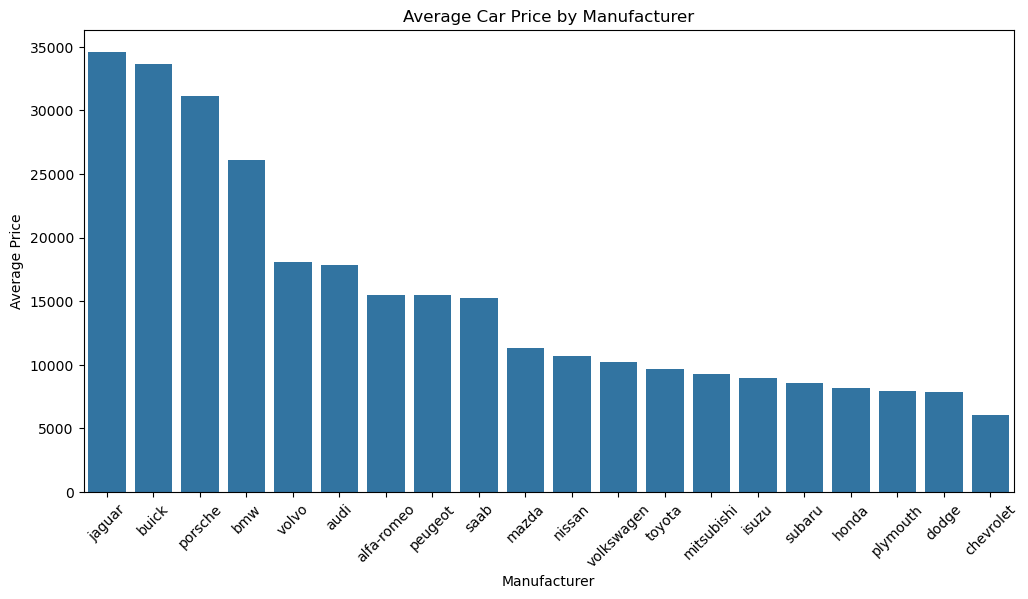

In [22]:
manufacturer_plot = (
    manufacturer_price
    .query('count >= 3')
    .sort_values('mean', ascending=False)
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=manufacturer_plot,
    x=manufacturer_plot.index,
    y='mean'
)

plt.xticks(rotation=45)
plt.xlabel('Manufacturer')
plt.ylabel('Average Price')
plt.title('Average Car Price by Manufacturer')
plt.show()

The above chart is more revealing of average manufacturer prices than the table containing descriptive stats. The bar chart also indicates a clear almost hyperbolic (or linear negative) trend from luxury cars to affordable brands on the American market. Consequently, we can infer that the manufacturer is an excellent car price predictor.

### Question 2: How do engine characteristics differ by manufacturer?

Here we explore another more subtle feature, namely whether manufacturers that have higher average prices also tend to produce larger or more powerful engines.

In [30]:
manufacturer_engine = (
    df.groupby('manufacturer')
    .agg(
        cars=('car_ID', 'count'),
        avg_price=('price', 'mean'),
        avg_engine_size=('enginesize', 'mean'),
        avg_horsepower=('horsepower', 'mean'),
        avg_curbweight=('curbweight', 'mean'),
        avg_city_mpg=('citympg', 'mean')
    )
    .sort_values('avg_price', ascending=False)
)

manufacturer_engine

,cars,avg_price,avg_engine_size,avg_horsepower,avg_curbweight,avg_city_mpg
manufacturer,,,,,,
jaguar,3,34600.000000,280.666667,204.666667,4027.333333,14.333333
buick,8,33647.000000,226.500000,146.250000,3696.250000,18.500000
porsche,5,31400.500000,187.200000,210.400000,2891.200000,17.400000
bmw,8,26118.750000,166.875000,138.875000,2929.375000,19.375000
volvo,11,18063.181818,142.272727,128.000000,3037.909091,21.181818
audi,7,17859.166714,130.714286,121.000000,2800.714286,18.857143
mercury,1,16503.000000,140.000000,175.000000,2910.000000,19.000000
toyouta,1,15750.000000,161.000000,156.000000,3151.000000,19.000000
alfa-romeo,3,15498.333333,137.333333,125.333333,2639.666667,20.333333


We can see that the price actually correlates with a number of engine features, and indeed larger or more poweful engines belong to more expensive cars (but also, that luxury car manufacturers produce larger, more powerful engines).

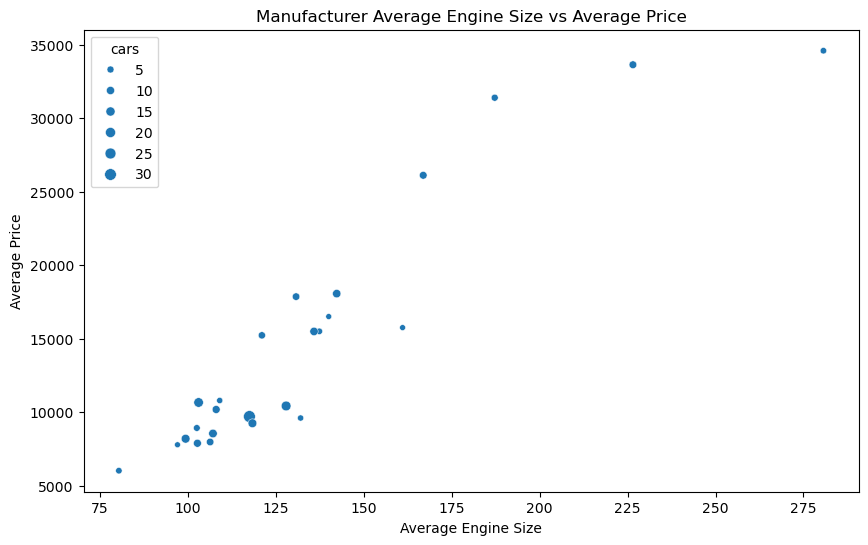

In [31]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=manufacturer_engine,
    x='avg_engine_size',
    y='avg_price',
    size='cars'
)

plt.xlabel('Average Engine Size')
plt.ylabel('Average Price')
plt.title('Manufacturer Average Engine Size vs Average Price')

plt.show()

The plot above shows a clear linear (or possibly asymptotic, but the data are not large enough to conclude such nuances) upward trend between engine size and average price. Therefore, engine size is also a strong car price predictor.

### Question 3: Are larger and heavier cars more expensive?

In this section, let's explore features related to car (not engine) size and their linear relationship using correlation (corr).

Chat GPT proposed selecting the following features related to car size, on which we applied a correlation function, showing that these features are all correlated with one another.

In [32]:
size_features = [
    'wheelbase',
    'carlength',
    'carwidth',
    'carheight',
    'curbweight',
    'price'
]

df[size_features].corr()

,wheelbase,carlength,carwidth,carheight,curbweight,price
wheelbase,1.000000,0.874587,0.795144,0.589435,0.776386,0.577816
carlength,0.874587,1.000000,0.841118,0.491029,0.877728,0.682920
carwidth,0.795144,0.841118,1.000000,0.279210,0.867032,0.759325
carheight,0.589435,0.491029,0.279210,1.000000,0.295572,0.119336
curbweight,0.776386,0.877728,0.867032,0.295572,1.000000,0.835305
price,0.577816,0.682920,0.759325,0.119336,0.835305,1.000000


Even if these correlations indicate multicollinearity, we can pick and combine some of these as overall size features (for example, a car that is just a line is not a car). We can infer that car size is also correlated with engine size, but this is a separate question. Let's view the car size correlations again in a more revealing heat map plot.

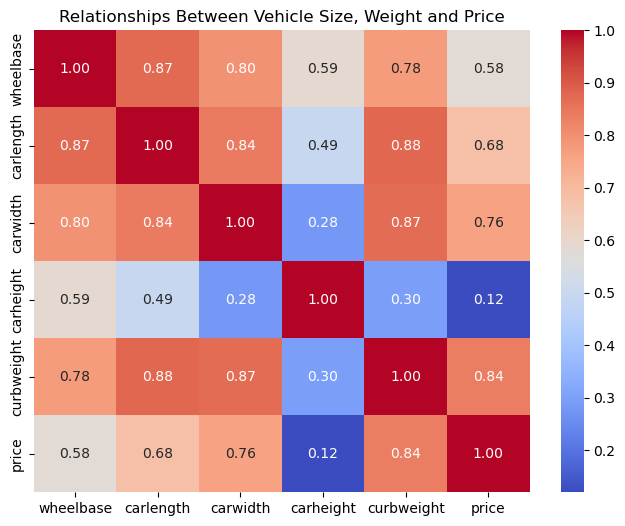

In [33]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df[size_features].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Relationships Between Vehicle Size, Weight and Price')
plt.show()

We can see how wheelbase, carlength, carwidth and curbweight are all highly correlated (>.7). Let's combine some of these into meaningful variables and plot them.

In [34]:
df['footprint'] = df['carlength'] * df['carwidth']

In [35]:
df[['footprint', 'curbweight', 'price']].corr()

,footprint,curbweight,price
footprint,1.000000,0.906811,0.738052
curbweight,0.906811,1.000000,0.835305
price,0.738052,0.835305,1.000000


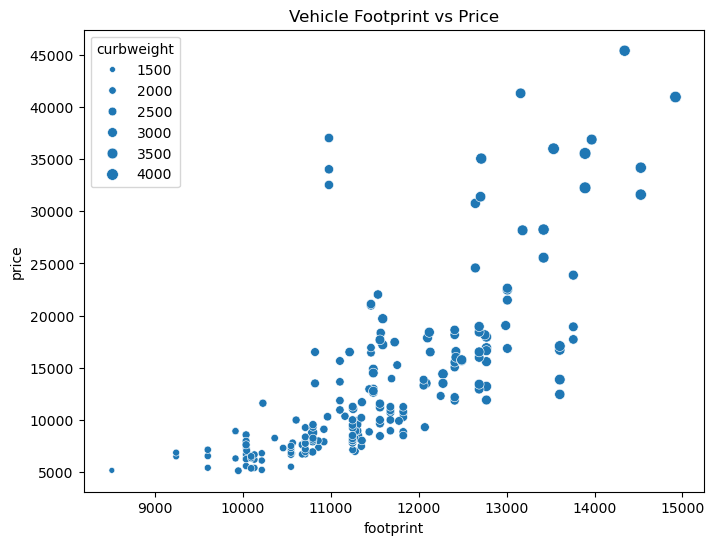

In [36]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='footprint',
    y='price',
    size='curbweight'
)

plt.title('Vehicle Footprint vs Price')
plt.show()

We have identified a number of car size elements which are strongly correlated with the average car price, and for simplicity, we created a new feature called 'footprint' describing an overall car size which combines these elements (namely, car width and car length). This, along with the curb weight, show a strong upward linear trend, predictive of the average price. Therefore, we can assert that car size is a strong indicator of car price. 

### Question 4: Can we identify groups of correlated vehicle characteristics?

This investigates the correlation structure of numerical variables, including those whose functions are less known. We will include multiple, seemingly unrelated variables which could be indicative of multicollinearity, in order to only extract relevant features for a potential machine learning model.

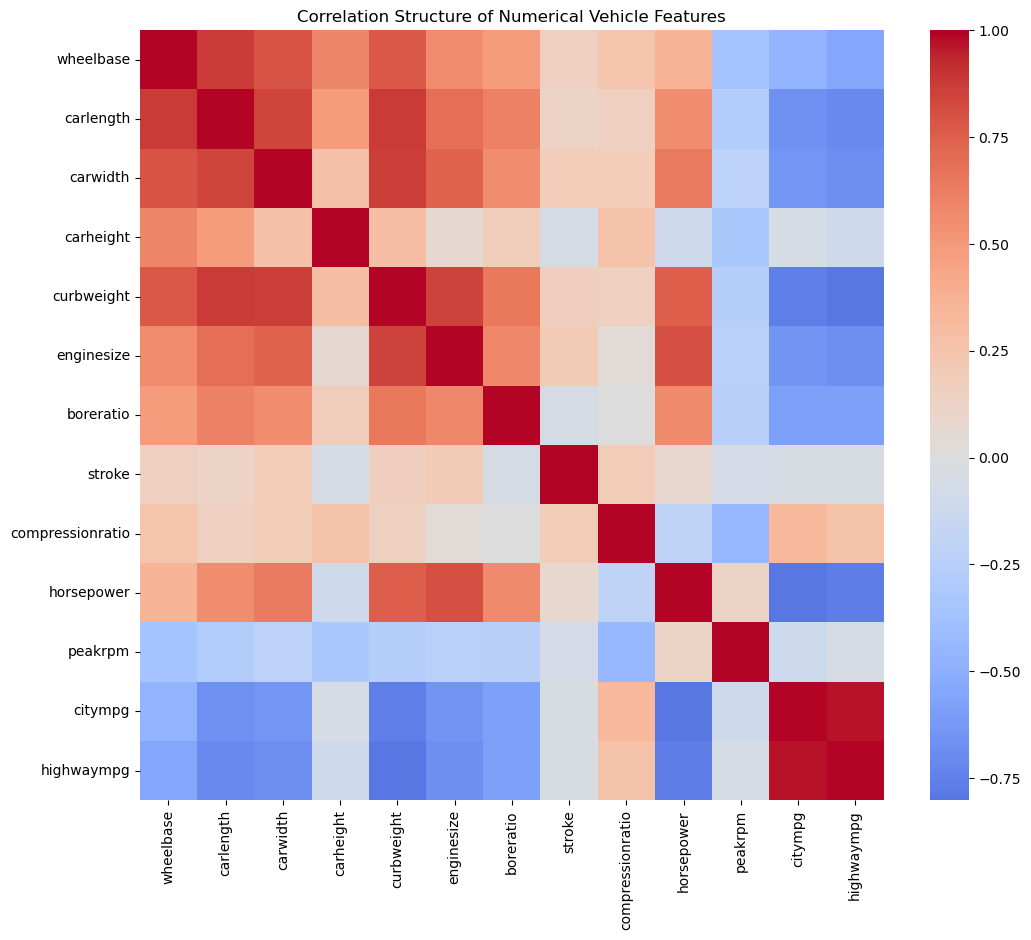

In [37]:
feature_groups = [
    'wheelbase',
    'carlength',
    'carwidth',
    'carheight',
    'curbweight',
    'enginesize',
    'boreratio',
    'stroke',
    'compressionratio',
    'horsepower',
    'peakrpm',
    'citympg',
    'highwaympg'
]

plt.figure(figsize=(12, 10))

sns.heatmap(
    df[feature_groups].corr(),
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Structure of Numerical Vehicle Features')
plt.show()

The idea is to exclude some of the highly correlated variables in case they measure the same thing, or are highly related (as gas mileage in the city and outside, citympg and highwaympg, are in this dataset), in order to avoid redundancy and overfitting in our model. We can further combine highly correlated variables into a single one, like we did in Question 3 for the variable 'footprint'. The idea is to use a small number of not-so-correlated variables to identify individual predictors of car price on the American market, where possible. However, the authors acknowledge their limitations and will stop here before delving into deeper expert research.

---

# Conclusions and next steps

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.